In [17]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
import camb
from camb import sources

In [18]:
mask = nmt.mask_apodization(hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask.fits"), 1., apotype="Smooth")

In [19]:
l_min = 300
l_max = 2900
delta_l = 200

In [20]:
ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

In [21]:
# l_min = 10      # your minimum multipole
# l_max = 1000    # your maximum multipole
# n_bins  = 10      # number of bins

# # Create log-spaced bin edges
# ell_edges = np.unique(np.geomspace(l_min, l_max, n_bins + 1).astype(int))

# Build the NaMaster bin object
b = nmt.NmtBin.from_edges(ells_low, ells_high)

In [22]:
delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/galaxy_samples/1_delta.fits", field=0)
nside_gal = hp.get_nside(delta_blue)
nside = nside_gal

In [23]:
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)

    return cl_decoupled

In [24]:
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

wsp_gal = nmt.NmtWorkspace()
wsp_gal.compute_coupling_matrix(gal_field, gal_field, b)
auto_gal = compute_master(gal_field, gal_field, wsp_gal)


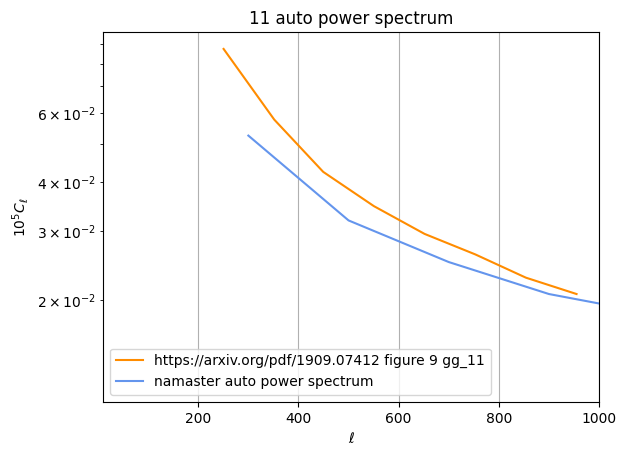

In [ ]:
arr = np.array([
    [955.0561797752808, 0.020716292134831504],
    [853.9325842696629, 0.022801966292134906],
    [752.808988764045, 0.026137640449438226],
    [651.6853932584269, 0.02947331460674163],
    [550.5617977528087, 0.034683988764044965],
    [449.4382022471908, 0.04239466292134833],
    [351.68539325842676, 0.057598314606741585],
    [250.56179775280896, 0.08718398876404494],
])

plt.plot(
    arr[:, 0],
    arr[:, 1],
    color="darkorange",
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_11"
)

plt.plot(
    ells_low,
    1e5 * auto_gal[0],
    color="cornflowerblue",
    label="namaster auto power spectrum"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(10, 1000)
plt.title("11 auto power spectrum")
plt.grid()
plt.legend()
plt.show()

### synthetic galaxy overdensity power spectrum

In [26]:
data = np.loadtxt("/home/gscianna/codes/CMBxunWISE/maps/normalised_dndz_cosmos.txt")
bias_blue  = lambda z: 0.8 + 1.2*z
z = data[:, 0]
dndz_blue = data[:, 1]

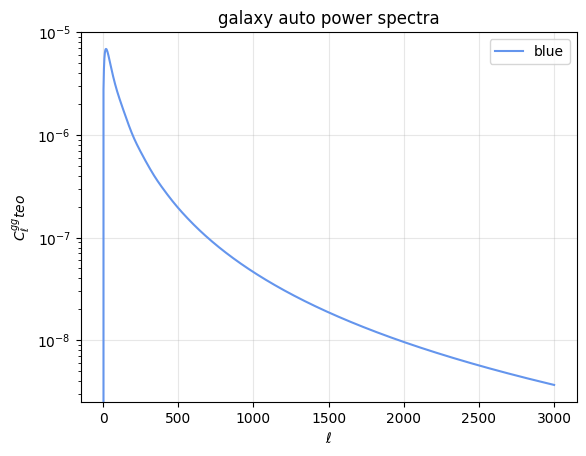

In [36]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.0224, omch2=0.120, mnu=0.06, tau=0.054)
pars.InitPower.set_params(As=2.1e-9, ns=0.965)

lmax = 3000
pars.set_for_lmax(lmax)

w_blue = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)
w_green = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)
w_red = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)

w_blue.set_table(z, dndz_blue, bias_z=bias_blue(z))

pars.SourceWindows = [w_blue]

pars.SourceTerms.counts_density = True
pars.SourceTerms.counts_redshift = False
pars.SourceTerms.counts_lensing = False
pars.SourceTerms.counts_velocity = False
pars.SourceTerms.counts_radial = False
pars.SourceTerms.counts_timedelay = False
pars.SourceTerms.counts_ISW = False
pars.SourceTerms.counts_potential = False

pars.SourceTerms.limber_windows = True

results = camb.get_results(pars)

cls = results.get_source_cls_dict(raw_cl=True)

cl_gg_teo  = cls["W1xW1"][:lmax+1]

ells = np.arange(len(cl_gg_teo))

plt.plot(ells, cl_gg_teo, label="blue", color="cornflowerblue")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{gg} teo$")
plt.yscale("log")
plt.title("galaxy auto power spectra")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### C_l estimator from real data

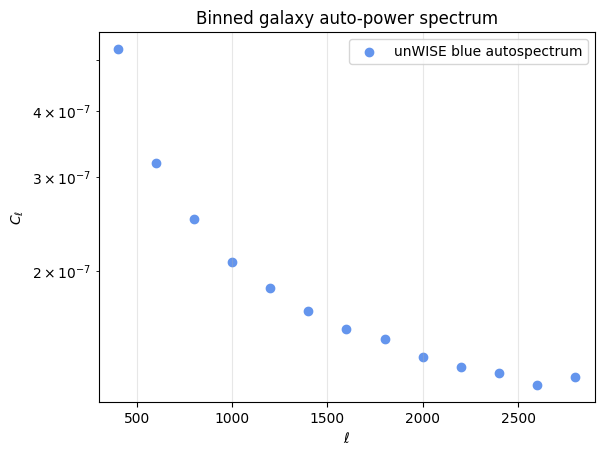

In [ ]:
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(gal_field, gal_field, b)

cl_gg_data = compute_master(gal_field, gal_field, wsp)
ell = b.get_effective_ells()

Dl_GG = ell * (ell + 1) * cl_gg_data[0] / (2 * np.pi)

plt.scatter(ell, cl_gg_data[0], label="unWISE blue autospectrum", color="cornflowerblue")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale("log")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned galaxy auto-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [45]:
def get_sample_field():
    mp_t = hp.synfast(cl_gg_teo, nside, new=True)
    return nmt.NmtField(mask, [mp_t])

gal_field_teo = get_sample_field()
gal_field_teo = nmt.NmtField(mask, [hp.synfast(cl_gg_teo, nside, new=True)], lmax=l_max)
wsp_teo = nmt.NmtWorkspace.from_fields(gal_field_teo, gal_field_teo, b)
n_ell = b.get_n_bands()

In [46]:
cwsp_teo = nmt.NmtCovarianceWorkspace.from_fields(gal_field_teo, gal_field_teo, gal_field_teo, gal_field_teo)

covar_00_00 = nmt.gaussian_covariance(cwsp_teo,
                                      0, 0, 0, 0,  # Spins of the 4 fields
                                      [cl_gg_teo],  # GG
                                      [cl_gg_teo],  # GG
                                      [cl_gg_teo],  # GG
                                      [cl_gg_teo],  # GG
                                      wsp_teo, wb=wsp_teo).reshape([n_ell, 1,
                                                            n_ell, 1])
covar_GG_GG = covar_00_00[:, 0, :, 0]

In [51]:
error_bars = np.sqrt(np.diag(covar_GG_GG))
ell_eff = b.get_effective_ells()

error_bars

array([4.88203218e-09, 1.71603621e-09, 7.99423235e-10, 4.37710993e-10,
       2.65731558e-10, 1.73397648e-10, 1.19364838e-10, 8.56352190e-11,
       6.34930409e-11, 4.83581988e-11, 3.76639850e-11, 2.98946864e-11,
       2.40272090e-11])

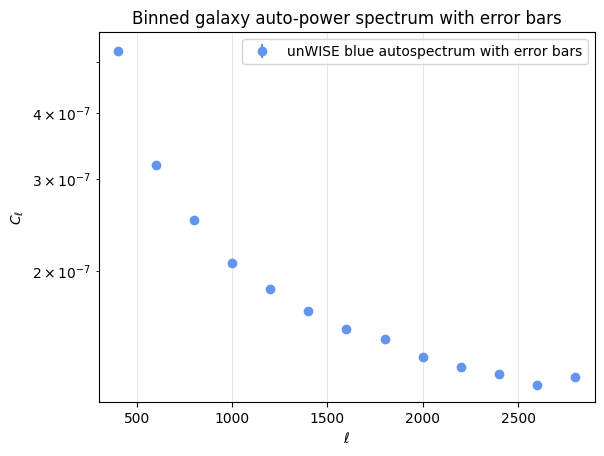

In [52]:
plt.errorbar(ell_eff, cl_gg_data[0], yerr=error_bars, fmt='o', label="unWISE blue autospectrum with error bars", color="cornflowerblue")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale("log")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned galaxy auto-power spectrum with error bars")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### prova prova

In [54]:
# real data field
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

# binning/workspace for the measured data spectrum
wsp_gal = nmt.NmtWorkspace.from_fields(gal_field, gal_field, b)

# measured binned spectrum
cl_gg_data = compute_master(gal_field, gal_field, wsp_gal)

# number of bandpowers
n_ell = b.get_n_bands()
ell_eff = b.get_effective_ells()

In [55]:
# covariance workspace: depends on mask/geometry, not on a simulated theory map
cwsp_gal = nmt.NmtCovarianceWorkspace.from_fields(
   gal_field, gal_field, gal_field, gal_field
)

In [56]:
cl_fid = cl_gg_teo.copy()
shot_noise = 1. / hp.nside2npix(nside) / np.mean(delta_blue + 1)
cl_fid_total = cl_fid + shot_noise

In [57]:
covar_00_00 = nmt.gaussian_covariance(
    cwsp_gal,
    0, 0, 0, 0,
    [cl_fid_total],
    [cl_fid_total],
    [cl_fid_total],
    [cl_fid_total],
    wsp_gal,
    wb=wsp_gal
).reshape([n_ell, 1, n_ell, 1])

covar_GG_GG = covar_00_00[:, 0, :, 0]
error_bars = np.sqrt(np.diag(covar_GG_GG))

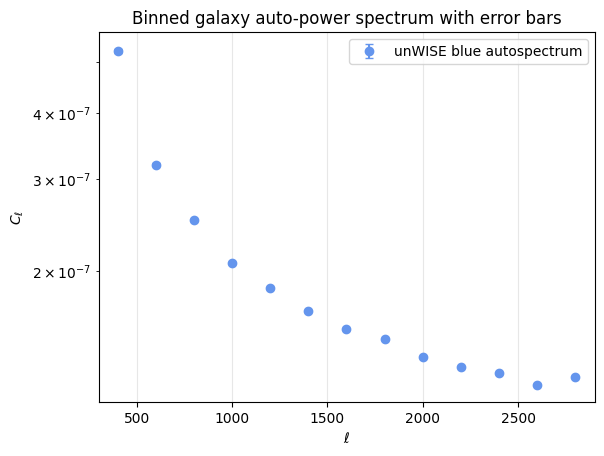

In [59]:
plt.errorbar(
    ell_eff,
    cl_gg_data[0],
    yerr=error_bars,
    fmt='o',
    capsize=3,
    label="unWISE blue autospectrum",
    color="cornflowerblue"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale("log")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned galaxy auto-power spectrum with error bars")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [60]:
print(cl_gg_data[0])
print(error_bars)
print(error_bars / cl_gg_data[0])

[5.24466188e-07 3.18939123e-07 2.49870826e-07 2.07148156e-07
 1.85386301e-07 1.67660651e-07 1.55005802e-07 1.48302311e-07
 1.37352876e-07 1.31358693e-07 1.27778886e-07 1.21575442e-07
 1.25633591e-07]
[5.17168512e-09 1.95408819e-09 1.00666139e-09 6.23518272e-10
 4.35568250e-10 3.30752547e-10 2.66622338e-10 2.24508900e-10
 1.95262744e-10 1.74009323e-10 1.57974133e-10 1.45489879e-10
 1.35071249e-10]
[0.00986086 0.00612684 0.00402873 0.00301001 0.00234952 0.00197275
 0.00172008 0.00151386 0.00142161 0.00132469 0.00123631 0.0011967
 0.00107512]


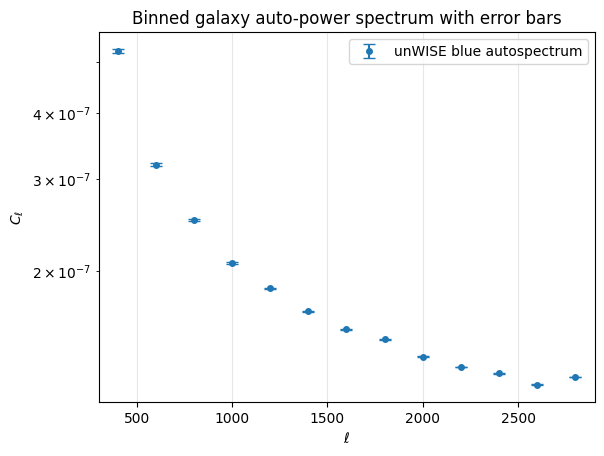

In [63]:
plt.errorbar(
    ell_eff,
    cl_gg_data[0],
    yerr=error_bars,
    fmt='o',
    capsize=4,
    elinewidth=1.5,
    markersize=4,
    label="unWISE blue autospectrum"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale("log")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned galaxy auto-power spectrum with error bars")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

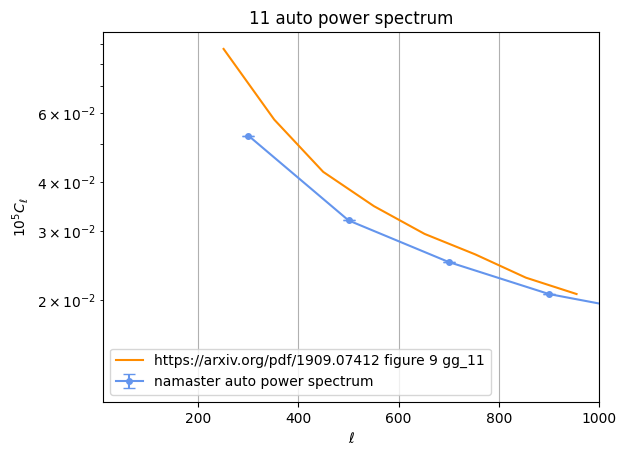

In [66]:
plt.plot(
    arr[:, 0],
    arr[:, 1],
    color="darkorange",
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_11"
)

plt.errorbar(
    ells_low,
    1e5 * auto_gal[0],
    color="cornflowerblue",
    yerr=error_bars,
    fmt='o-',
    capsize=4,
    elinewidth=1.5,
    markersize=4,
    label="namaster auto power spectrum"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(10, 1000)
plt.title("11 auto power spectrum")
plt.grid()
plt.legend()
plt.show()